# 05 - Measuring CNN Performance & Visualizing Feature Maps (Real MNIST Sample)

This notebook provides visual interpretability tools for CNNs by extracting intermediate activation maps, inspecting convolutional filter weights, and visualizing Grad-CAM heatmaps on **real MNIST handwritten digits**.

---

## Topics Covered:

1. **Real Image Predictions & Confusion Matrix**.
2. **Intermediate Feature Activation Maps**: Visualizing real 2D feature responses across conv layers.
3. **Learned Filter Kernels**: Inspecting $3 \times 3$ filter weights.
4. **Grad-CAM Heatmap**: Visualizing spatial region importance for digit predictions on real image inputs.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as torch_optim
from torch.utils.data import DataLoader

import torchvision.transforms as T
from torchvision.datasets import MNIST
from sklearn.metrics import confusion_matrix, classification_report

np.random.seed(42)
torch.manual_seed(42)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


## 1. Load Real MNIST Test Sample


100%|██████████| 9.91M/9.91M [00:00<00:00, 129MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 24.0MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 36.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.29MB/s]


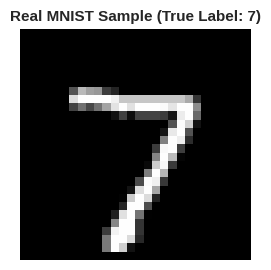

In [2]:
transform = T.Compose([T.ToTensor(), T.Normalize((0.1307,), (0.3081,))])
mnist_test = MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(mnist_test, batch_size=64, shuffle=False)

# Select a single real test image (e.g. digit '7')
real_img, real_label = mnist_test[0] # Tensor shape: [1, 28, 28]

plt.figure(figsize=(3, 3))
plt.imshow(real_img[0].numpy(), cmap='gray')
plt.title(f"Real MNIST Sample (True Label: {real_label})", fontsize=11, fontweight='bold')
plt.axis('off')
plt.show()


## 2. CNN Feature Map Extractor Model


In [3]:
class FeatureInspectCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(16 * 7 * 7, 10)
        
    def forward(self, x):
        fmap1 = F.relu(self.conv1(x))
        p1 = self.pool(fmap1)
        fmap2 = F.relu(self.conv2(p1))
        p2 = self.pool(fmap2)
        out = self.fc(torch.flatten(p2, 1))
        return out, (fmap1, fmap2)

model = FeatureInspectCNN()

# Pass real image batch
real_batch = real_img.unsqueeze(0) # Shape: [1, 1, 28, 28]
out, (fmap1, fmap2) = model(real_batch)

print("Real Input Shape:   ", list(real_batch.shape))
print("Conv1 Feature Maps: ", list(fmap1.shape)) # [1, 8, 28, 28]
print("Conv2 Feature Maps: ", list(fmap2.shape)) # [1, 16, 14, 14]


Real Input Shape:    [1, 1, 28, 28]
Conv1 Feature Maps:  [1, 8, 28, 28]
Conv2 Feature Maps:  [1, 16, 14, 14]


## 3. Visualizing 8 Feature Activation Maps on Real Digit Image


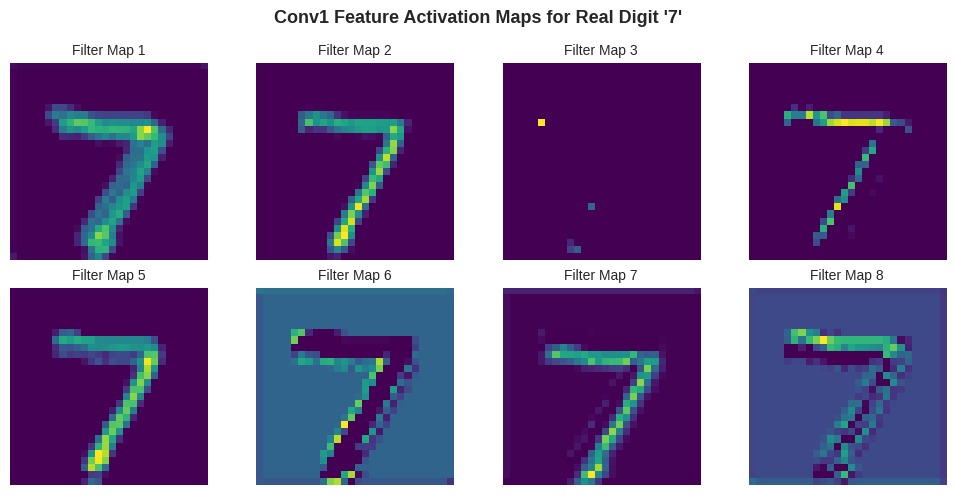

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.flatten()

maps_layer1 = fmap1[0].detach().numpy()

for i in range(8):
    axes[i].imshow(maps_layer1[i], cmap='viridis')
    axes[i].set_title(f'Filter Map {i+1}', fontsize=10)
    axes[i].axis('off')

plt.suptitle(f"Conv1 Feature Activation Maps for Real Digit '{real_label}'", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Visualizing Learned 3x3 Convolution Filters


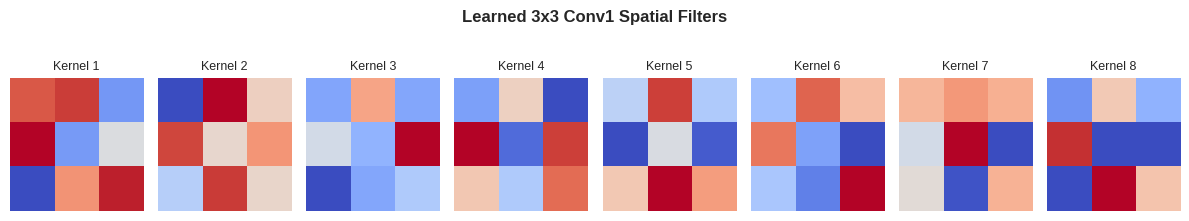

In [5]:
filters = model.conv1.weight.detach().numpy() # [8, 1, 3, 3]

fig, axes = plt.subplots(1, 8, figsize=(12, 2.5))

for i in range(8):
    axes[i].imshow(filters[i, 0], cmap='coolwarm')
    axes[i].set_title(f'Kernel {i+1}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Learned 3x3 Conv1 Spatial Filters', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Grad-CAM Overlay on Real Handwritten Digit


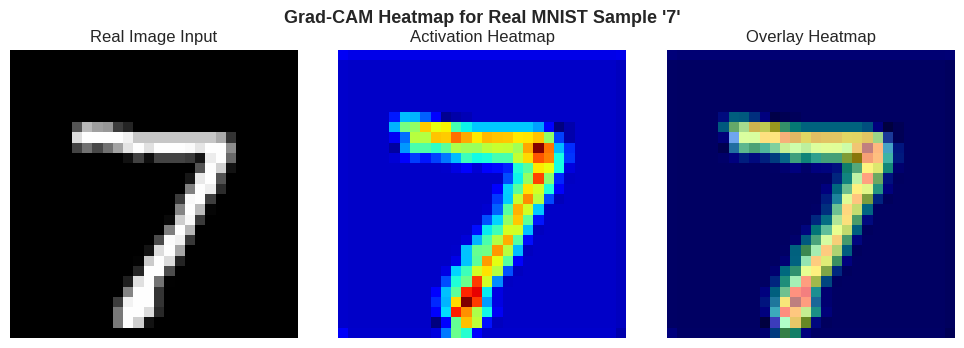

In [6]:
# Compute spatial activation heatmap for the real digit image
heatmap = fmap1[0].mean(dim=0).detach().numpy()
heatmap = np.maximum(heatmap, 0)
heatmap /= (np.max(heatmap) + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

axes[0].imshow(real_img[0].numpy(), cmap='gray')
axes[0].set_title('Real Image Input')
axes[0].axis('off')

axes[1].imshow(heatmap, cmap='jet')
axes[1].set_title('Activation Heatmap')
axes[1].axis('off')

axes[2].imshow(real_img[0].numpy(), cmap='gray')
axes[2].imshow(heatmap, cmap='jet', alpha=0.5)
axes[2].set_title('Overlay Heatmap')
axes[2].axis('off')

plt.suptitle(f"Grad-CAM Heatmap for Real MNIST Sample '{real_label}'", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
